In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
path = '../../Data' 
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# Khởi tạo dictionary để chứa các bản copy đã sạch (hoặc chuẩn bị làm sạch)
data_cleansed = {}

for file in files:
    # 1. Tách tên file để làm key (vd: 'sales_data.csv' -> 'sales_data')
    file_name = os.path.splitext(file)[0]
    full_path = os.path.join(path, file)
    
    # 2. Đọc file gốc
    df_temp = pd.read_csv(full_path)
    
    # 3. Tạo bản copy và lưu vào dictionary với định dạng key là df_<name>
    # Sử dụng .copy() để đảm bảo đây là một bản sao độc lập hoàn toàn
    dict_key = f"df_{file_name}"
    data_cleansed[dict_key] = df_temp.copy()
    
    print(f"Đã lưu bản copy vào dictionary: data_cleansed['{dict_key}']")

# Ví dụ cách truy cập sau khi load:
# print(data_cleansed['df_ten_file_cua_ban'].head())

Đã lưu bản copy vào dictionary: data_cleansed['df_customers']
Đã lưu bản copy vào dictionary: data_cleansed['df_geography']
Đã lưu bản copy vào dictionary: data_cleansed['df_inventory']
Đã lưu bản copy vào dictionary: data_cleansed['df_orders']


C:\Users\ngami\AppData\Local\Temp\ipykernel_22984\1533433001.py:13: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_temp = pd.read_csv(full_path)


Đã lưu bản copy vào dictionary: data_cleansed['df_order_items']
Đã lưu bản copy vào dictionary: data_cleansed['df_payments']
Đã lưu bản copy vào dictionary: data_cleansed['df_products']
Đã lưu bản copy vào dictionary: data_cleansed['df_promotions']
Đã lưu bản copy vào dictionary: data_cleansed['df_returns']
Đã lưu bản copy vào dictionary: data_cleansed['df_reviews']
Đã lưu bản copy vào dictionary: data_cleansed['df_sales']
Đã lưu bản copy vào dictionary: data_cleansed['df_sample_submission']
Đã lưu bản copy vào dictionary: data_cleansed['df_shipments']
Đã lưu bản copy vào dictionary: data_cleansed['df_web_traffic']


**PROMOTIONS

In [3]:
# Lấy các bảng ra từ dictionary
df_items = data_cleansed['df_order_items']
df_promo = data_cleansed['df_promotions']
df_prod = data_cleansed['df_products']
# Bước 1: Kết nối đơn hàng với sản phẩm để lấy Category và Price gốc
df_merged = df_items.merge(df_prod[['product_id', 'category', 'price', 'product_name']], 
                           on='product_id', how='left')

# Bước 2: Kết nối với bảng Promotions để lấy thông tin chiến dịch
# Lưu ý: Ta merge cho promo_id chính, bạn có thể làm tương tự cho promo_id_2 nếu muốn
df_merged = df_merged.merge(df_promo, left_on='promo_id', right_on='promo_id', how='left')
df_merged = df_merged.merge(df_promo, left_on='promo_id_2', right_on='promo_id', how='left', suffixes=('', '_p2'))

# Bước 3: Tính toán các chỉ số bổ trợ
df_merged['revenue_actual'] = df_merged['quantity'] * df_merged['unit_price']
df_merged['revenue_before_discount'] = df_merged['quantity'] * df_merged['price']
df_merged['is_promo'] = (df_merged['promo_id'].notna()|df_merged['promo_id_2'].notna()).map({True: 'Có KM', False: 'Không KM'})

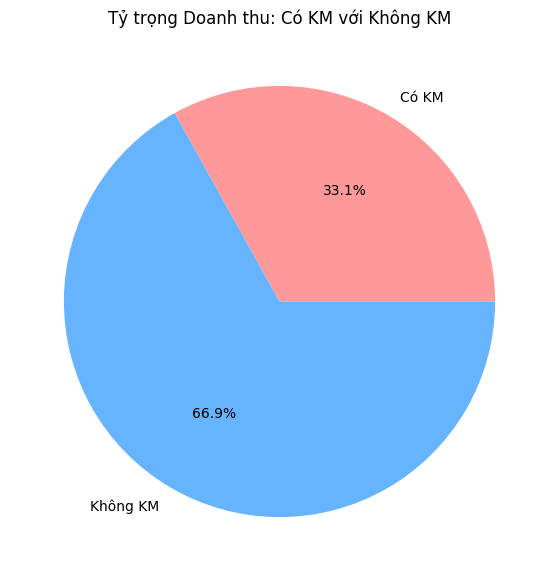

In [4]:
plt.figure(figsize=(7, 7))
revenue_by_promo = df_merged.groupby('is_promo')['revenue_actual'].sum()
plt.pie(revenue_by_promo, labels=revenue_by_promo.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Tỷ trọng Doanh thu: Có KM với Không KM')
plt.show()

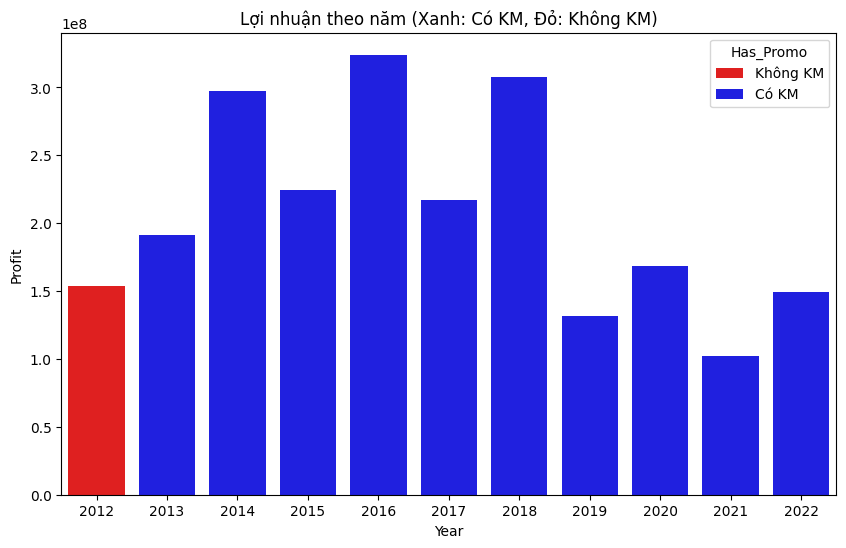

In [5]:
# 1. Chuẩn bị dữ liệu
df_sales = data_cleansed['df_sales']
df_promo = data_cleansed['df_promotions']

df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

# 2. Xác định các năm có KM
years_with_promo = set()
for _, row in df_promo.iterrows():
    s_yr = row['start_date'].year
    e_yr = row['end_date'].year
    for yr in range(s_yr, e_yr + 1):
        years_with_promo.add(yr)

# 3. Tính lợi nhuận theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

df_yearly.columns = ['Year', 'Revenue', 'COGS']
df_yearly['Profit'] = df_yearly['Revenue'] - df_yearly['COGS']
df_yearly['Has_Promo'] = df_yearly['Year'].apply(lambda x: 'Có KM' if x in years_with_promo else 'Không KM')

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(data=df_yearly, x='Year', y='Profit', hue='Has_Promo', 
            palette={'Có KM': 'blue', 'Không KM': 'red'})

plt.title('Lợi nhuận theo năm (Xanh: Có KM, Đỏ: Không KM)')
plt.show()

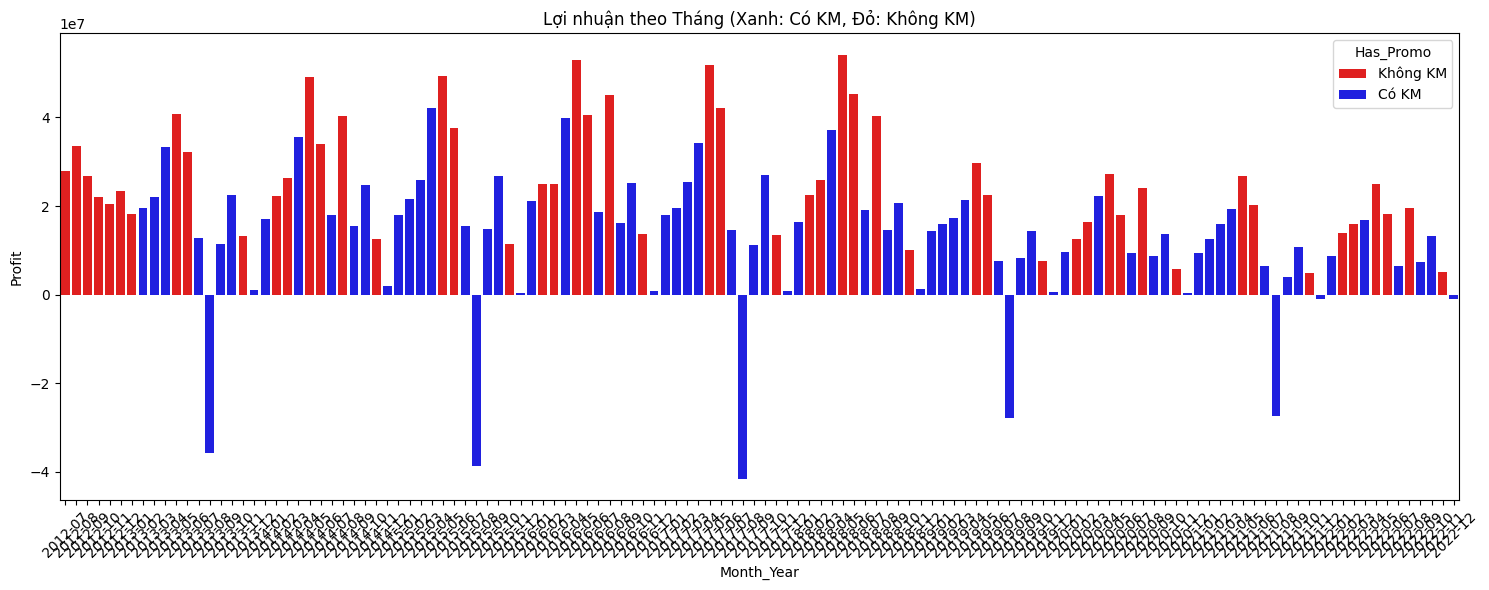

In [6]:
# 1. Chuẩn bị dữ liệu ngày tháng
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_promo['start_date'] = pd.to_datetime(df_promo['start_date'])
df_promo['end_date'] = pd.to_datetime(df_promo['end_date'])

# 2. Xác định các THÁNG có khuyến mãi
# Ta dùng định dạng 'YYYY-MM' để lưu trữ các tháng có KM
months_with_promo = set()
for _, row in df_promo.iterrows():
    # Tạo một chuỗi thời gian từ start_date đến end_date
    date_range = pd.date_range(start=row['start_date'], end=row['end_date'], freq='MS') 
    for d in date_range:
        months_with_promo.add(d.strftime('%Y-%m'))
    # Đảm bảo tháng kết thúc cũng được tính (phòng trường hợp end_date không phải đầu tháng)
    months_with_promo.add(row['end_date'].strftime('%Y-%m'))

# 3. Gom nhóm doanh thu theo Tháng
# Tạo cột 'Month_Year' định dạng YYYY-MM để vẽ biểu đồ
df_sales['Month_Year'] = df_sales['Date'].dt.strftime('%Y-%m')

df_monthly = df_sales.groupby('Month_Year').agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 4. Tính lợi nhuận và đánh dấu KM
df_monthly['Profit'] = df_monthly['Revenue'] - df_monthly['COGS']
df_monthly['Has_Promo'] = df_monthly['Month_Year'].apply(lambda x: 'Có KM' if x in months_with_promo else 'Không KM')

# 5. Sắp xếp lại theo thời gian để biểu đồ không bị đảo lộn
df_monthly = df_monthly.sort_values('Month_Year')

# 6. Vẽ biểu đồ
plt.figure(figsize=(15, 6))
sns.barplot(data=df_monthly, x='Month_Year', y='Profit', hue='Has_Promo', 
            palette={'Có KM': 'blue', 'Không KM': 'red'}, dodge=False)

plt.xticks(rotation=45) # Xoay tên tháng cho dễ đọc
plt.title('Lợi nhuận theo Tháng (Xanh: Có KM, Đỏ: Không KM)')
plt.tight_layout()
plt.show()

**RETURN

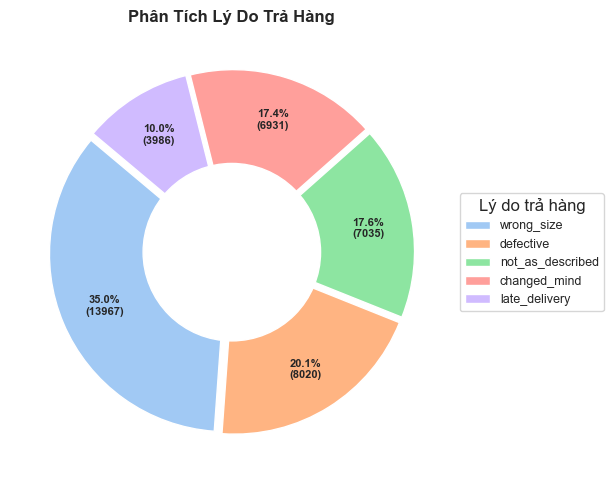

In [40]:
# Giả định dữ liệu đã có sẵn
reason_counts = df_returns['return_reason'].value_counts().reset_index()
reason_counts.columns = ['reason', 'count']

# 1. PHẢI ĐỊNH NGHĨA BIẾN NÀY TRƯỚC KHI VẼ
pct_idx = list(range(len(reason_counts)))

# Hàm định dạng nhãn bên trong (chỉ hiển thị số liệu để tránh chật chội)
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute:d})"

plt.figure(figsize=(7, 5)) # Size nhỏ gọn

# 2. Vẽ biểu đồ
wedges, texts, autotexts = plt.pie(
    reason_counts['count'], 
    autopct=lambda pct: func(pct, reason_counts['count']),
    startangle=140, 
    colors=sns.color_palette('pastel'),
    pctdistance=0.75,      # Đưa số liệu vào trong miếng bánh
    explode=[0.03] * len(reason_counts),
    textprops={'fontsize': 8, 'fontweight': 'bold'} # Chỉnh chữ số liệu nhỏ lại
)

# 3. Thêm Legend (Chú thích) ở bên cạnh để không lơ lửng
plt.legend(
    wedges, 
    reason_counts['reason'],
    title="Lý do trả hàng",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Đẩy bảng chú thích ra ngoài phía bên phải
    fontsize=9
)

# Tạo hình tròn trắng ở giữa (Donut)
centre_circle = plt.Circle((0,0), 0.50, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Phân Tích Lý Do Trả Hàng', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Sai size (wrong_size) chiếm tỷ trọng cao nhất (~14,000)
→ Đây là vấn đề lớn nhất, cho thấy trải nghiệm chọn size chưa tốt hoặc thông tin size không rõ ràng.
Sản phẩm lỗi (defective) đứng thứ 2 (~8,000)
→ Chất lượng sản phẩm hoặc kiểm soát chất lượng (QC) đang có vấn đề đáng kể.
Không giống mô tả & đổi ý (not_as_described, changed_mind ~7,000)
→
“Không giống mô tả” phản ánh nội dung sản phẩm (hình ảnh/mô tả) chưa chính xác
“Đổi ý” cho thấy kỳ vọng khách hàng chưa được quản lý tốt
Giao hàng trễ (late_delivery ~4,000)
→ Ít hơn nhưng vẫn ảnh hưởng đến trải nghiệm tổng thể

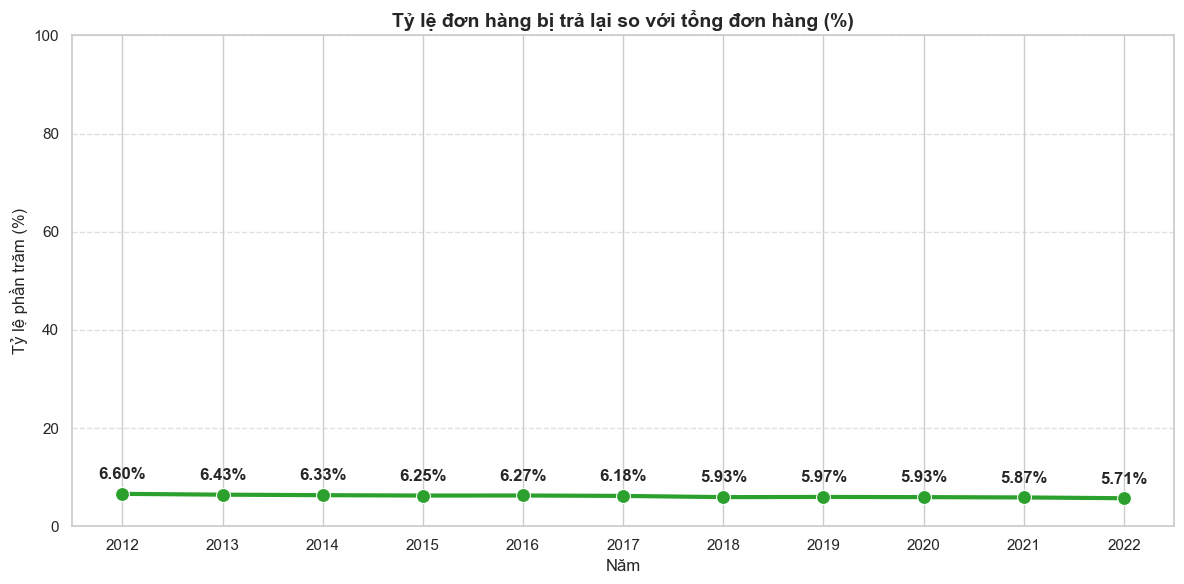

In [41]:
# Giả định data_cleansed chứa các DataFrame tương ứng
df_orders = data_cleansed['df_orders']
df_returns = data_cleansed['df_returns']

# 1. Chuẩn hóa định dạng ngày tháng
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['order_year'] = df_orders['order_date'].dt.year

# 2. Merge bảng: Trái (Orders) với Phải (Returns) để giữ tất cả đơn hàng
# Sử dụng 'how=left' để những đơn không bị trả sẽ có giá trị NaN ở các cột của bảng returns
df_merged = pd.merge(df_orders, df_returns[['order_id', 'return_id']], on='order_id', how='left')

# 3. Tính toán thống kê theo năm
# Đếm tổng số đơn hàng và số đơn hàng có return_id (tức là bị trả)
yearly_stats = df_merged.groupby('order_year').agg(
    total_orders=('order_id', 'nunique'),
    returned_orders=('return_id', 'nunique')
).reset_index()

# 4. Tính tỷ lệ phần trăm
yearly_stats['return_rate'] = (yearly_stats['returned_orders'] / yearly_stats['total_orders']) * 100

# 5. Vẽ biểu đồ Line Graph thể hiện tỷ lệ %
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=yearly_stats, 
    x='order_year', 
    y='return_rate', 
    marker='o', 
    markersize=10, 
    linewidth=3, 
    color='#2ca02c' # Màu xanh lá để phân biệt với biểu đồ số lượng
)

# Thiết lập trục Oy từ 0 đến 100%
plt.ylim(0, 100)

# Thêm nhãn % trên từng điểm
for i in range(yearly_stats.shape[0]):
    plt.text(
        yearly_stats.order_year[i], 
        yearly_stats.return_rate[i] + 3, 
        f"{yearly_stats.return_rate[i]:.2f}%", 
        ha='center', 
        fontweight='bold'
    )

plt.title('Tỷ lệ đơn hàng bị trả lại so với tổng đơn hàng (%)', fontsize=14, fontweight='bold')
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tỷ lệ phần trăm (%)', fontsize=12)
plt.xticks(yearly_stats['order_year'])
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

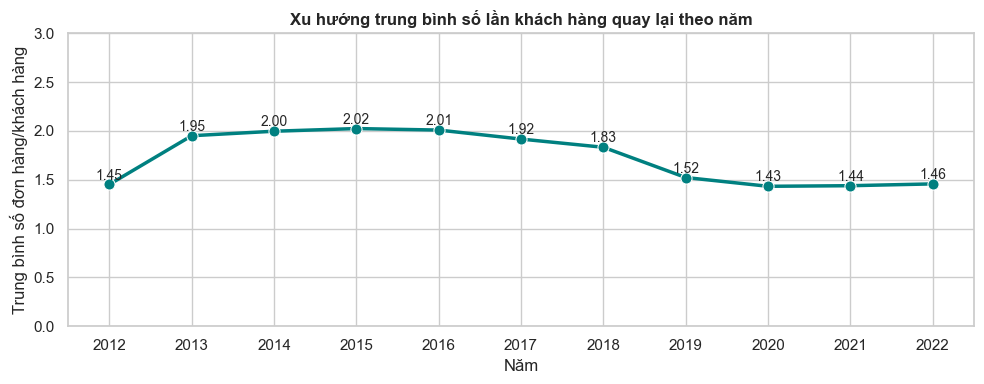

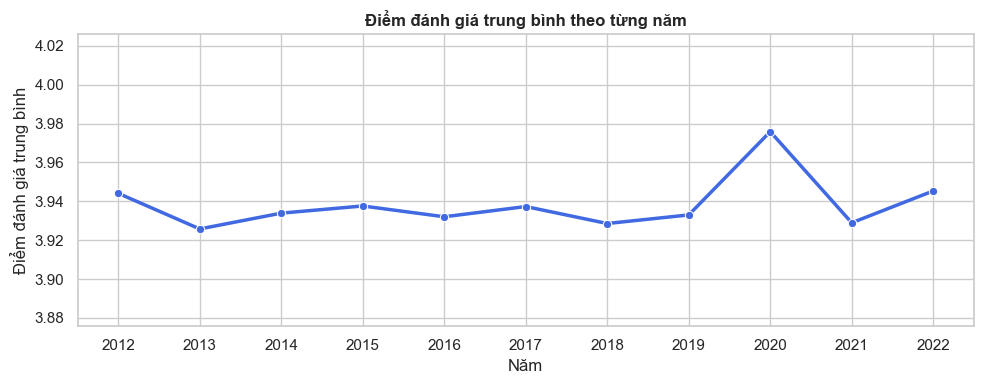

In [30]:
# ==============================
# 1. SETUP CHUNG
# ==============================

sns.set_theme(style="whitegrid")

df_orders = data_cleansed['df_orders'].copy()

# Convert datetime + extract year
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['order_year'] = df_orders['order_date'].dt.year

# ==============================
# 2. CUSTOMER RETENTION ANALYSIS
# ==============================

# Số đơn hàng mỗi customer theo năm
customer_retention = (
    df_orders
    .groupby(['order_year', 'customer_id'])
    .size()
    .reset_index(name='order_count')
)

# Trung bình số đơn hàng / customer theo năm
yearly_avg_orders = (
    customer_retention
    .groupby('order_year')['order_count']
    .mean()
    .reset_index()
)

# ==============================
# 3. PLOT: CUSTOMER RETENTION TREND
# ==============================
plt.figure(figsize=(10, 4))

ax = sns.lineplot(
    data=yearly_avg_orders,
    x='order_year',
    y='order_count',
    marker='o',
    markersize=8,
    linewidth=2.5,
    color='teal'
)

# Add labels
for x, y in zip(yearly_avg_orders['order_year'], yearly_avg_orders['order_count']):
    plt.text(x, y + 0.05, f"{y:.2f}", ha='center', fontsize=10)

plt.title('Xu hướng trung bình số lần khách hàng quay lại theo năm', fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Trung bình số đơn hàng/khách hàng')
plt.xticks(yearly_avg_orders['order_year'])
plt.ylim(0, 3)

plt.tight_layout()
plt.show()


# ==============================
# 4. PREPARE DATA - REVIEWS
# ==============================
df_reviews = data_cleansed['df_reviews'].copy()

# Merge orders + reviews
df_merged = pd.merge(
    df_reviews,
    df_orders[['order_id', 'order_date']],
    on='order_id',
    how='inner'
)

# Extract year
df_merged['order_date'] = pd.to_datetime(df_merged['order_date'])
df_merged['year'] = df_merged['order_date'].dt.year

# ==============================
# 5. RATING ANALYSIS
# ==============================
yearly_rating = (
    df_merged
    .groupby('year')['rating']
    .mean()
    .reset_index()
)

# ==============================
# 6. PLOT: RATING TREND
# ==============================
plt.figure(figsize=(10, 4))

sns.lineplot(
    data=yearly_rating,
    x='year',
    y='rating',
    marker='o',
    linewidth=2.5,
    color='royalblue'
)

plt.title('Điểm đánh giá trung bình theo từng năm', fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Điểm đánh giá trung bình')
plt.xticks(yearly_rating['year'])
min_rating = yearly_rating['rating'].min()
max_rating = yearly_rating['rating'].max()
diff = max_rating - min_rating
min_rating = max(1.0, min_rating - diff)  # Đảm bảo không thấp hơn 1.0
max_rating = min(5.0, max_rating + diff)  # Đảm bảo không cao hơn 5.0
plt.ylim(min_rating, max_rating)
plt.tight_layout()
plt.show()

**Phân tích hành vi của khách hàng 
*Lưu ý, ở biểu đồ "Điểm đánh giá trung bình theo từng năm", ta hiển thị cột Oy đi từ round(min_rating - diff, 1) đến round(max_rating + diff, 1) để thấy rõ sự khác biệt
Dựa vào 2 chart-> năm 2020 có rating cao nhất nhưng đồng thời số lần khách hàng quay lại cửa hàng cũng là thấp nhất.
Có thể do: Năm dịch nên các cửa hàng đều chuyển sang thương mại điện tử -> cạnh tranh với nhau khốc liệt hơn-> mặc dù rating tăng cao nhưng số lần khách hàng quay lại lần 2 lại giảm xuống

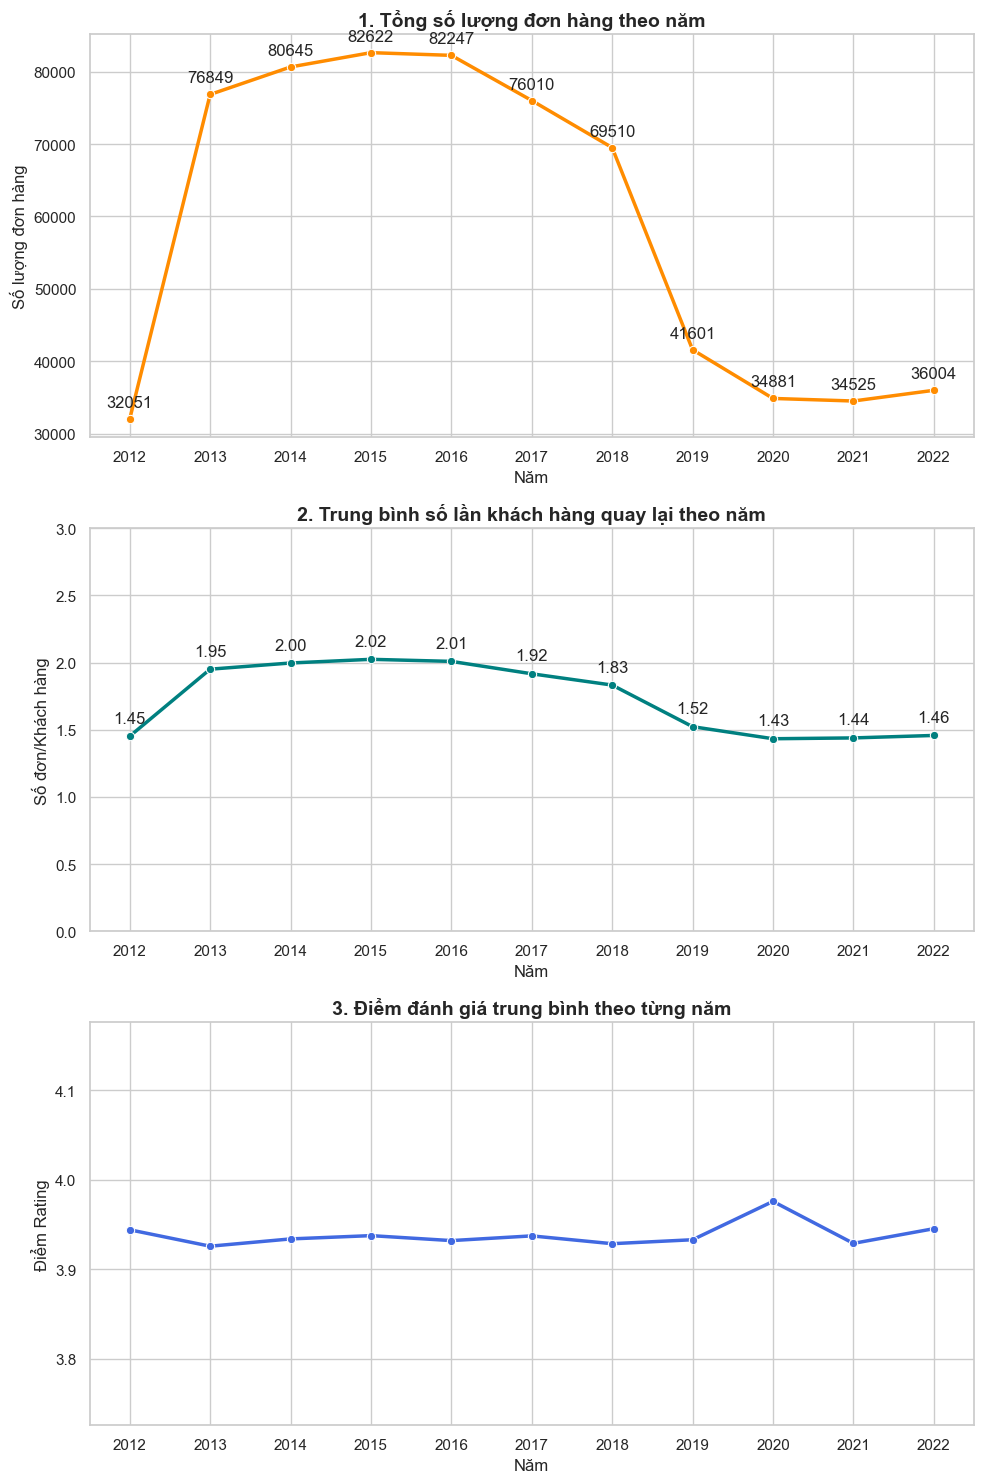

In [42]:
# ==============================
# 1. CHUẨN BỊ DỮ LIỆU BỔ SUNG: ORDER VOLUME
# ==============================
yearly_order_volume = (
    df_orders
    .groupby('order_year')
    .size()
    .reset_index(name='total_orders')
)

# ==============================
# 2. VẼ TỔNG HỢP 3 BIỂU ĐỒ (SUBPLOTS)
# ==============================
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
sns.set_theme(style="whitegrid")

# --- BIỂU ĐỒ 1: SỐ LƯỢNG ĐƠN HÀNG (Order Volume) ---
sns.lineplot(
    data=yearly_order_volume, 
    x='order_year', y='total_orders', 
    marker='o', color='darkorange', linewidth=2.5, ax=axes[0]
)
axes[0].set_title('1. Tổng số lượng đơn hàng theo năm', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Số lượng đơn hàng')
for x, y in zip(yearly_order_volume['order_year'], yearly_order_volume['total_orders']):
    axes[0].text(x, y + (max(yearly_order_volume['total_orders'])*0.02), f"{int(y)}", ha='center')

# --- BIỂU ĐỒ 2: RETENTION (Số lần quay lại) ---
sns.lineplot(
    data=yearly_avg_orders, 
    x='order_year', y='order_count', 
    marker='o', color='teal', linewidth=2.5, ax=axes[1]
)
axes[1].set_title('2. Trung bình số lần khách hàng quay lại theo năm', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Số đơn/Khách hàng')
axes[1].set_ylim(0, 3)
for x, y in zip(yearly_avg_orders['order_year'], yearly_avg_orders['order_count']):
    axes[1].text(x, y + 0.1, f"{y:.2f}", ha='center')

# --- BIỂU ĐỒ 3: RATING (Chất lượng) ---
sns.lineplot(
    data=yearly_rating, 
    x='year', y='rating', 
    marker='o', color='royalblue', linewidth=2.5, ax=axes[2]
)
axes[2].set_title('3. Điểm đánh giá trung bình theo từng năm', fontweight='bold', fontsize=14)
axes[2].set_ylabel('Điểm Rating')

# Tối ưu hóa trục Y cho Rating
r_min, r_max = yearly_rating['rating'].min(), yearly_rating['rating'].max()
axes[2].set_ylim(max(1.0, r_min - 0.2), min(5.0, r_max + 0.2))

# Cấu hình chung cho cả 3
for ax in axes:
    ax.set_xlabel('Năm')
    ax.set_xticks(yearly_order_volume['order_year'])

plt.tight_layout()
plt.show()

# 🔍 **1. Giai đoạn tăng trưởng mạnh (2012–2016)**

**Hiện tượng:**
- Đơn hàng tăng nhanh: ~32k → ~82k
- Tần suất mua lại tăng: 1.45 → ~2.0
- Rating ổn định ~3.93–3.94

**Chẩn đoán:**
Doanh nghiệp đang scale rất tốt:
- Mở rộng tệp khách hàng
- Sản phẩm/giá phù hợp thị trường
- Tần suất mua lại tăng → customer retention tốt
- Rating không tăng nhiều → chất lượng ổn định nhưng chưa xuất sắc

**👉 Insight:**  
**Đây là giai đoạn "growth driven by acquisition + decent retention", chưa phải nhờ trải nghiệm vượt trội.**

# <mark>**⚠️ 2. Giai đoạn chững & suy giảm (2017–2019)**</mark>

**<mark>Hiện tượng:</mark>**
- <mark>Đơn hàng giảm: 82k → 69k → 41k</mark>
- <mark>Tần suất mua lại giảm: 2.0 → 1.52</mark>
- <mark>Rating gần như không đổi</mark>

**<mark>Điểm bất thường:</mark>**  
**<mark>👉 Rating không giảm nhưng khách vẫn rời bỏ</mark>**

**<mark>Chẩn đoán sâu:</mark>**  
<mark>Đây là dấu hiệu điển hình của:</mark>

1. **<mark>"Hidden dissatisfaction" (bất mãn ngầm)</mark>**  
   <mark>Rating ~3.9 là không tệ nhưng cũng không đủ tốt để giữ chân</mark>  
   <mark>Khách không complain mạnh → nhưng âm thầm rời đi</mark>
2. **<mark>Trải nghiệm không khác biệt</mark>**  
   <mark>Sản phẩm "ổn" nhưng:</mark>  
   <mark>Không có lý do quay lại</mark>  
   <mark>Dễ bị thay thế bởi đối thủ</mark>
3. **<mark>Có thể xuất hiện vấn đề vận hành:</mark>**  
   <mark>Dựa trên biểu đồ trả hàng trước đó:</mark>  
   <mark>Sai size, hàng lỗi, mô tả sai → tích tụ theo thời gian</mark>  
   <mark>→ làm giảm loyalty (thể hiện qua tần suất quay lại giảm)</mark>

**<mark>👉 Insight quan trọng:</mark>**  
**<mark>Doanh nghiệp không mất khách vì "tệ", mà vì "không đủ tốt để giữ khách"</mark>**

# <mark>**💥 3. Giai đoạn sụt giảm mạnh (2019–2020)**</mark>

**<mark>Hiện tượng:</mark>**
- <mark>Đơn hàng giảm cực mạnh: 69k → 41k → 34k</mark>
- <mark>Tần suất mua lại chạm đáy: ~1.43</mark>
- <mark>Rating lại tăng nhẹ (~3.98)</mark>

**<mark>Chẩn đoán:</mark>**
1. **<mark>Tác động thị trường (rất lớn)</mark>**  
   <mark>Đây trùng với giai đoạn COVID-19</mark>  
   <mark>→ Đứt gãy:</mark>  
   <mark>Chuỗi cung ứng</mark>  
   <mark>Logistic</mark>  
   <mark>Hành vi tiêu dùng</mark>
2. **<mark>"Survivor bias" trong rating</mark>**  
   <mark>Khách khó tính đã rời đi từ trước</mark>  
   <mark>Chỉ còn:</mark>  
   <mark>Nhóm khách trung thành / dễ tính hơn</mark>  
   <mark>→ Rating tăng nhưng không phản ánh tăng trưởng thực</mark>

**<mark>👉 Insight:</mark>**  
**<mark>Rating tăng trong khi doanh thu giảm = dấu hiệu nguy hiểm (false positive metric)</mark>**

# 🧊 **4. Giai đoạn hồi phục nhẹ (2021–2022)**

**Hiện tượng:**
- Đơn hàng hồi nhẹ (~34k → 36k)
- Tần suất mua lại gần như không tăng (~1.44–1.46)
- Rating ổn định

**Chẩn đoán:**
Doanh nghiệp chưa giải quyết gốc rễ vấn đề  
Phục hồi chủ yếu do:  
Thị trường hồi phục  
Không phải do cải thiện nội tại

**👉 Insight:**  
**Business đang "stabilize ở mức thấp", chưa quay lại quỹ đạo tăng trưởng**